In [14]:
import h5py
import numpy as np
import glob

### Load & investigate template bank

In [23]:
filename = "BNSonly_bank.hdf"
with h5py.File(filename, 'r') as f:
    mass1 = f['mass1'][:]
    mass2 = f['mass2'][:]
    spin1z = f['spin1z'][:]
    spin2z = f['spin2z'][:]
    
    print("Number of templates:", len(mass1))
    print("First 5 templates:")
    for i in range(5):
        print(f"Template {i}: m1={mass1[i]}, m2={mass2[i]}, s1z={spin1z[i]}, s2z={spin2z[i]}")

Number of templates: 19602
First 5 templates:
Template 0: m1=2.5000056435534317, m2=2.5000056435534317, s1z=0.0, s2z=0.0
Template 1: m1=2.499016671015672, m2=2.499016671015672, s1z=0.0, s2z=0.0
Template 2: m1=2.4980309843846458, m2=2.4980309843846458, s1z=0.0, s2z=0.0
Template 3: m1=2.4970381946270375, m2=2.4970381946270375, s1z=0.0, s2z=0.0
Template 4: m1=2.4960664280862677, m2=2.4960664280862677, s1z=0.0, s2z=0.0


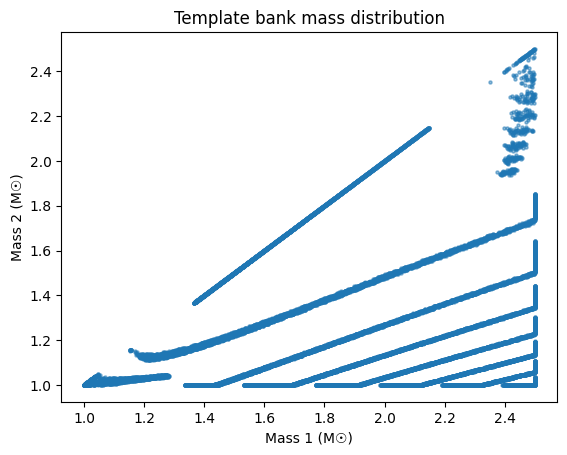

In [24]:
# plot template bank mass distribution
import matplotlib.pyplot as plt

plt.scatter(mass1, mass2, s=5, alpha=0.5)
plt.xlabel("Mass 1 (M☉)")
plt.ylabel("Mass 2 (M☉)")
plt.title("Template bank mass distribution")
plt.show()

### Loading in the signals

In [25]:
file_list = glob.glob('/n/home03/creissel/SparseBank/data/generation/signals/sig_*.h5')

merged_data = {}

# Loop over all files
for file_path in file_list:
    with h5py.File(file_path, 'r') as f:
        for key in ['mass_1', 'mass_2']:
            data = f[key][()]  # Load dataset into numpy array
            if key in merged_data:
                # Concatenate along the first axis
                merged_data[key] = np.concatenate((merged_data[key], data), axis=0)
            else:
                merged_data[key] = data

In [26]:
sig_mass1 = merged_data['mass_1']
sig_mass2 = merged_data['mass_2']

In [35]:
import numpy as np
unc = 0.01
counts = []
total = mass1.shape[0]
for m1,m2 in zip(sig_mass1, sig_mass2):
    mask1 = (mass1 > ((1-unc)*m1)) & (mass1 < (1+unc)*m1)
    mask2 = (mass2 > ((1-unc)*m2)) & (mass2 < (1+unc)*m2)
    
    count = np.sum(mask1 & mask2)
    counts.append(count)

In [36]:
counts = np.array(counts)
# if there are no templates in the range replace the counting by one since we would only run one (the closest) template
counts[counts == 0.] = 1

In [37]:
print(np.mean(counts), np.median(counts), np.std(counts))

14.389852216748768 1.0 28.636702404583914


In [38]:
np.mean(counts)/total

0.0007341012252193025